# Ethiopia Climate Data Analysis (2015–2026)

This notebook performs data profiling, cleaning, and exploratory data analysis (EDA) on Ethiopia's climate dataset to identify trends in temperature, rainfall, and other weather variables.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (8,5)

In [7]:
df = pd.read_csv("C:/Users/USER/Desktop/10_acadamiy/climate-challenge-week0/data/data/ethiopia.csv")
df["Country"] = "Ethiopia"

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia


In [8]:
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["DATE"].dt.month

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


The YEAR and DOY columns were combined to create a proper datetime column. A Month column was extracted to support seasonal analysis.

In [9]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,Month
0,2015,1,11.73,22.75,3.44,19.31,0.00,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.00,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.00,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.00,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.00,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17,Ethiopia,2026-03-27,3
4104,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29,Ethiopia,2026-03-28,3
4105,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42,Ethiopia,2026-03-29,3
4106,2026,89,17.66,25.31,11.08,14.23,0.85,68.88,2.02,3.80,76.44,10.64,Ethiopia,2026-03-30,3


The value -999 represents missing or invalid data in NASA datasets. It was replaced with NaN to ensure accurate statistical analysis.

In [10]:
df.duplicated().sum()

np.int64(0)

No duplicate rows were found in the dataset. This indicates that the data collection process did not introduce repeated records, and no rows needed to be removed.

In [11]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


### Summary Statistics Interpretation

The dataset contains 4,108 daily observations spanning from 2015 to 2026, providing a comprehensive view of Ethiopia’s climate over time.

The average temperature (T2M) is approximately 16.07°C, with values ranging from about 10.03°C to 21.53°C. This indicates a relatively mild climate with moderate seasonal variation. The average maximum temperature (T2M_MAX) reaches about 23.2°C, while the minimum temperature (T2M_MIN) can drop to around 1.17°C, showing noticeable daily temperature fluctuations.

Rainfall (PRECTOTCORR) shows high variability, with a mean of 3.63 mm but a maximum of 82.3 mm. This suggests that precipitation is unevenly distributed, with occasional heavy rainfall events, likely corresponding to seasonal rainy periods.

Relative humidity (RH2M) averages around 68.4%, ranging from 14.42% to over 91%, indicating varying moisture conditions throughout the year.

Wind speed (WS2M) remains relatively low and stable, with an average of about 1.98 m/s, suggesting generally calm wind conditions.

Overall, the data indicates moderate temperatures, strong seasonal rainfall patterns, and variability in humidity, which are typical characteristics of Ethiopia’s climate.

In [12]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

missing_percent

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
DATE           0.0
Month          0.0
dtype: float64

### Missing Values Analysis

No missing values were found in the dataset after replacing the sentinel value (-999) with NaN. All columns have 0% missing data, indicating a complete dataset suitable for analysis without additional imputation.

In [13]:
from scipy.stats import zscore

cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]

z_scores = np.abs(zscore(df[cols], nan_policy='omit'))
outliers = (z_scores > 3).sum()

outliers

np.int64(137)

### Outlier Detection

Outliers were identified using the Z-score method, where values with a Z-score greater than 3 were considered extreme. A total of 137 outlier values were detected across the selected climate variables.

These outliers may represent extreme weather events such as heavy rainfall or unusually high or low temperatures, which are important in climate analysis. Therefore, instead of removing them, they were retained to preserve meaningful environmental variability.

In [15]:
df = df.ffill()

Since no missing values were present in the dataset, no imputation was required. However, forward-fill was applied as a precautionary step to maintain consistency in the workflow.

In [17]:
df.to_csv("C:/Users/USER/Desktop/10_acadamiy/climate-challenge-week0/data/data/ethiopia_clean.csv", index=False)

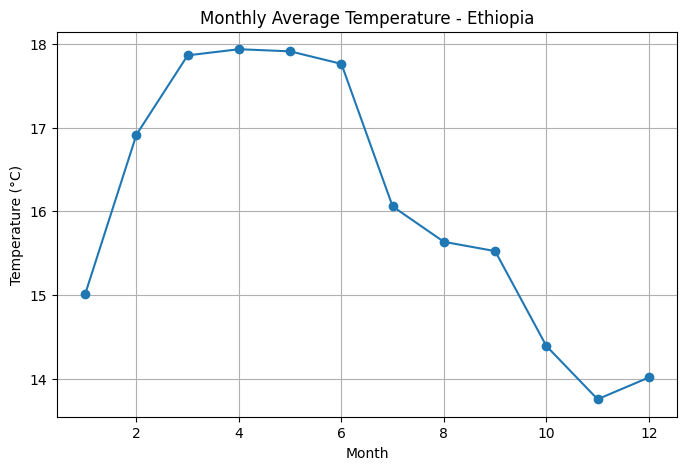

In [18]:
monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot(marker='o')
plt.title("Monthly Average Temperature - Ethiopia")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.grid()
plt.show()

### Temperature Trends

The monthly average temperature in Ethiopia shows a clear seasonal pattern. Temperatures increase from January and reach their peak around April, making it the warmest month.

After June, temperatures begin to decline gradually, with the lowest values observed around November, indicating the coolest period of the year.

Overall, the trend reflects a typical seasonal cycle, with a warm period in the early part of the year followed by a cooler period toward the end of the year.

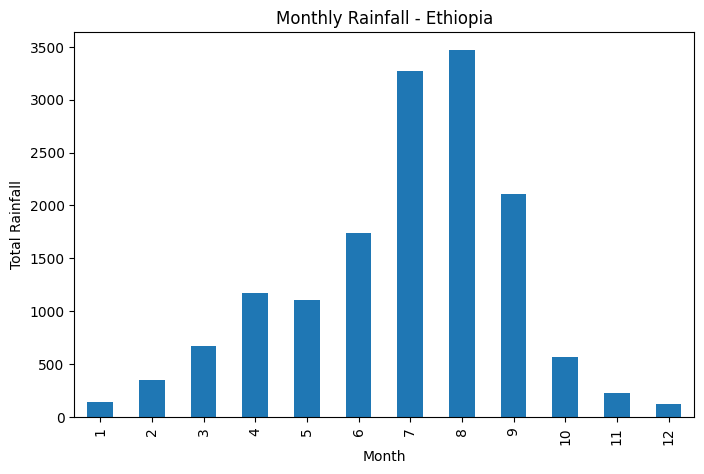

In [19]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")
plt.title("Monthly Rainfall - Ethiopia")
plt.xlabel("Month")
plt.ylabel("Total Rainfall")
plt.show()

### Rainfall Patterns

Rainfall in Ethiopia shows a strong seasonal pattern. The highest rainfall occurs between June and September, with a peak in July and August. This period represents the main rainy season.

In contrast, rainfall is very low between November and February, indicating a pronounced dry season. This clear distinction between wet and dry periods highlights the seasonal nature of precipitation in Ethiopia.

These patterns are important for agriculture and water resource management, as they determine planting seasons and water availability.

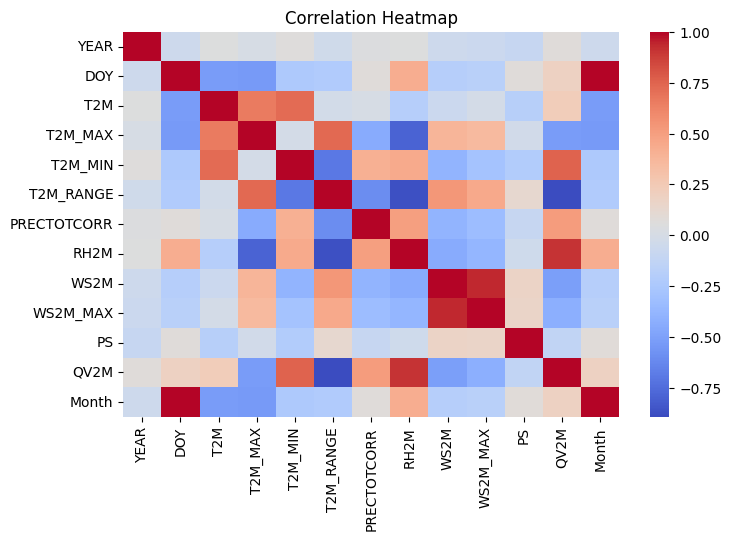

In [20]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Correlation Analysis

The correlation heatmap reveals several strong relationships between climate variables.

First, wind speed variables (WS2M and WS2M_MAX) show a very strong positive correlation, indicating that higher average wind speeds are associated with higher maximum wind speeds.

Second, temperature variables (T2M, T2M_MAX, and T2M_MIN) are highly positively correlated, suggesting that increases in average temperature are consistently reflected in both daily maximum and minimum temperatures.

Third, relative humidity (RH2M) and specific humidity (QV2M) also exhibit a strong positive correlation. This indicates that as atmospheric moisture increases, both humidity measures rise together.

Additionally, a negative relationship between temperature range (T2M_RANGE) and minimum temperature suggests that warmer nights reduce daily temperature variability.

These relationships are important for understanding climate dynamics and interactions between atmospheric variables.

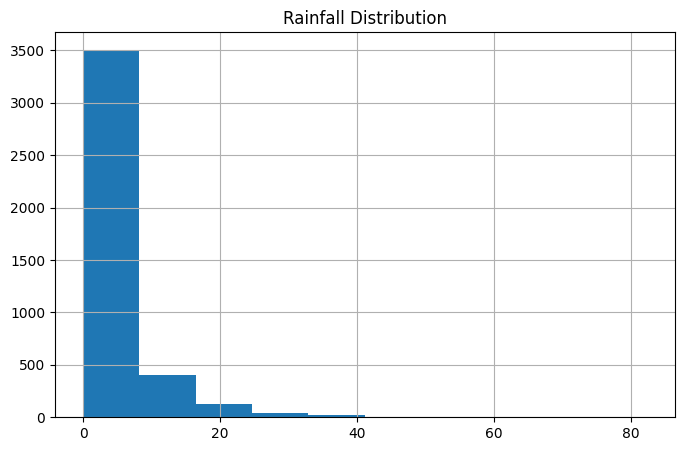

In [21]:
df["PRECTOTCORR"].hist()
plt.title("Rainfall Distribution")
plt.show()

### Rainfall Distribution

The distribution of rainfall is highly right-skewed, with most values concentrated at lower levels and a small number of extreme high values.

This indicates that the majority of days experience little to moderate rainfall, while a few days receive very heavy precipitation.

Such a pattern is characteristic of seasonal climates, where rainfall occurs in concentrated periods rather than being evenly distributed throughout the year.

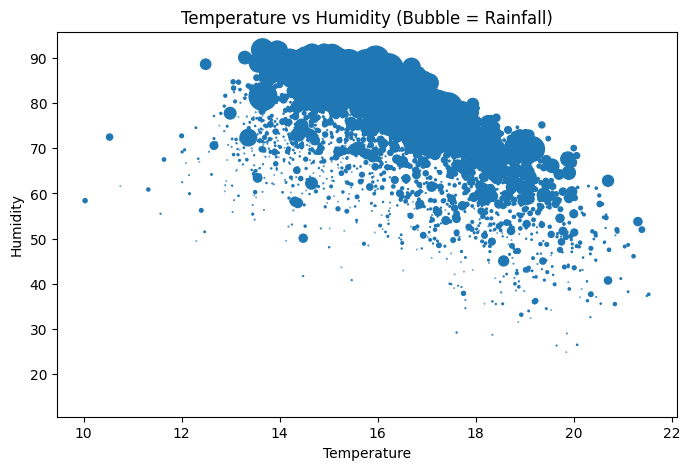

In [22]:
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*10)
plt.title("Temperature vs Humidity (Bubble = Rainfall)")
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.show()

### Temperature, Humidity, and Rainfall Relationship

The bubble chart shows a clear negative relationship between temperature and humidity, where higher temperatures are associated with lower humidity levels.

Rainfall, represented by bubble size, is generally higher in conditions of high humidity and moderate temperatures. Larger bubbles are concentrated in areas with higher moisture levels, indicating that rainfall is closely linked to atmospheric humidity.

In contrast, high-temperature and low-humidity conditions correspond to minimal rainfall, highlighting the dry climate periods.

This relationship emphasizes the role of humidity in driving precipitation patterns and provides insight into the climatic dynamics of Ethiopia.